Coding Assignment #5 Sentiment Analysis

In [1]:
import pandas as pd
import numpy as np
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#sample dataset (really small)

positive_reviews = [
"The product is excellent, I love it!", 
"Very good quality, worth every peso.", 
"Fast delivery and great packaging.", 
"Item arrived in perfect condition.", 
"Super satisfied with this purchase.", 
"Amazing product! Works perfectly.", 
"Highly recommended seller!", 
"Great value for the price.", 
"The material feels premium.",
"Exactly as described. Very happy!",
"Five stars, will order again.",
"Exceeded my expectations!",
"The color and design are beautiful.",
"Very useful and durable.",
"Everything works as advertised.",
"Good quality for the price.", 
"Seller is responsive and kind.", 
"Smooth transaction. Thanks!",
"Legit product, highly recommended!", 
"My favorite purchase this month.",
]

negative_reviews = [
"Terrible quality, not worth the money.", 
"Very disappointed. Stopped working after one day.", 
"Item arrived damaged and unusable.", 
"The product feels very cheap.", 
"Not what I expected at all.", 
"Shipping took too long.", 
"The item is defective.",
"Completely useless, waste of money.", 
"Wrong item was delivered.",
"Poor quality materials used.",
"The product did not match the description.", 
"Customer service was unhelpful.",
"Battery drains too fast.",
"Arrived with scratches and dents.",
"I regret buying this product.",
"It broke after a few uses.",
"Size is incorrect. Doesn't fit.",
"Very low quality, would not recommend.", 
"Not durable. Quickly damaged.",
"Disappointed. Expected better." 
]

#since dataset is incredibly small, we will duplicate entries (never good practice but for sake of demo)
df = pd.DataFrame({
    "review": positive_reviews * 5 + negative_reviews * 5,
    "sentiment":["positive"] * 100 + ["negative"] * 100
})

#shuffle/sample the dataset
df = df.sample(frac = 1, random_state = 42).reset_index(drop = True)
print(df.head())
print("DF size: ", len(df))

                          review sentiment
0    Good quality for the price.  positive
1    Good quality for the price.  positive
2  Five stars, will order again.  positive
3  Not durable. Quickly damaged.  negative
4      Wrong item was delivered.  negative
DF size:  200


In [3]:
#generate a train test split  80/20

X = df["review"]
y = df["sentiment"]

x_train, x_test , y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

print("Train Sample Size:", len(x_train))
print("Test Sample Size:", len(x_test))

Train Sample Size: 160
Test Sample Size: 40


In [4]:
#perform TF-IDF vectorization
vectorizer = TfidfVectorizer(
    stop_words= "english"
)
X_train_tfidf = vectorizer.fit_transform(x_train)
X_test_tfidf = vectorizer.transform(x_test)

In [5]:
#train the LR
model = LogisticRegression(max_iter = 200)
model.fit(X_train_tfidf, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'



METRICS:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        20
    positive       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



Text(45.722222222222214, 0.5, 'Actual')

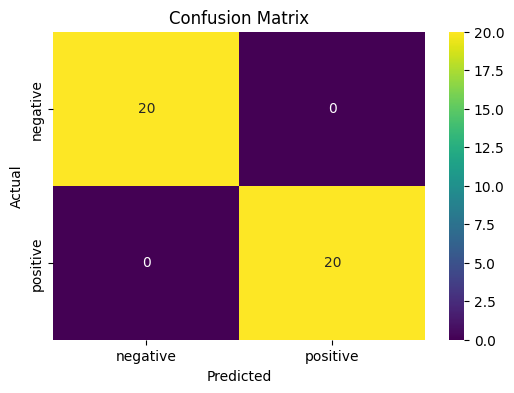

In [6]:
#generate predictions and get metrics
y_pred = model.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label = "positive")
recall = recall_score(y_test, y_pred, pos_label= "positive")
f1 = f1_score(y_test, y_pred, pos_label="positive")


print("\nMETRICS:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

#conf matrix
cm = confusion_matrix(y_test, y_pred)
#plot the cm
plt.figure(figsize = (6,4))

sns.heatmap(cm, annot = True, fmt = "d", cmap = "viridis",
            xticklabels= ["negative", "positive"],
            yticklabels=['negative', 'positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')


Hilariously good, mainly due to massive amounts of duplication, real tests with other data will show its lack of generalization

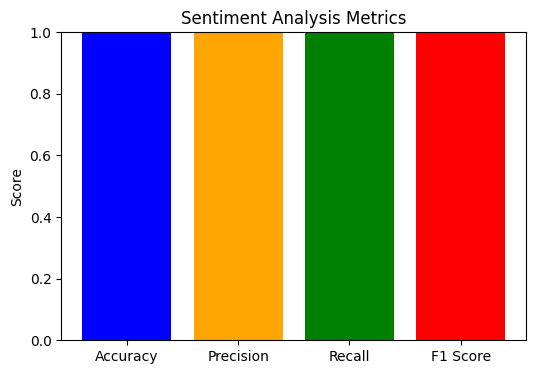

In [7]:
#illustration of metrics
metrics = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": recall,
    "F1 Score": f1
}

plt.figure(figsize=(6,4))
plt.bar(metrics.keys(), metrics.values(), color=['blue', 'orange', 'green', 'red'])
plt.title('Sentiment Analysis Metrics')
plt.ylabel('Score')
#limit to 1 as scores can only be in that range
plt.ylim(0,1)
plt.show()

In [8]:
def predict_sentiment(rev):
    #preprocess same to our df and run through the model
    rev_pre = vectorizer.transform([rev])
    pred = model.predict(rev_pre)[0] #get val at first index as it is the actual pred

    #add a rule for neutral sentiment by setting a threshold
    proba = model.predict_proba(rev_pre).max()

    if proba < 0.55:
        return "neutral"
    
    return pred


In [10]:
print("\n=====================")
print("Try the model! enter a review below:")
print("========================\n")

user_rev = input("Enter your review: ")
result = predict_sentiment(user_rev)

print("\nPredicted Sentiment:", result)


Try the model! enter a review below:


Predicted Sentiment: negative
